EXPERIMENT 6
MONTE CARLO PREDICTION AND CONTROL

AIM
---------------------------------------------------------------------------
To implement Monte Carlo Prediction and Monte Carlo Control
for estimating state values and learning an optimal policy
in a Reinforcement Learning environment.

THEORY
---------------------------------------------------------------------------
Monte Carlo methods learn from complete episodes.
Monte Carlo Prediction estimates the value of states.
Monte Carlo Control learns an optimal policy.
The return is calculated from the rewards obtained
after visiting a state.

Return Formula:
G(t) = R(t+1) + gamma*R(t+2) + gamma^2*R(t+3) + ...


MONTE CARLO PREDICTION
Monte Carlo Prediction Completed.
Episodes : 1000
Execution Time : 0.03184 seconds

Monte Carlo Prediction Results
---------------------------------------------------------------------------
   State  Estimated Value  Visits
0  Start             -1.0    1000
1     S1              0.0       0
2     S2       

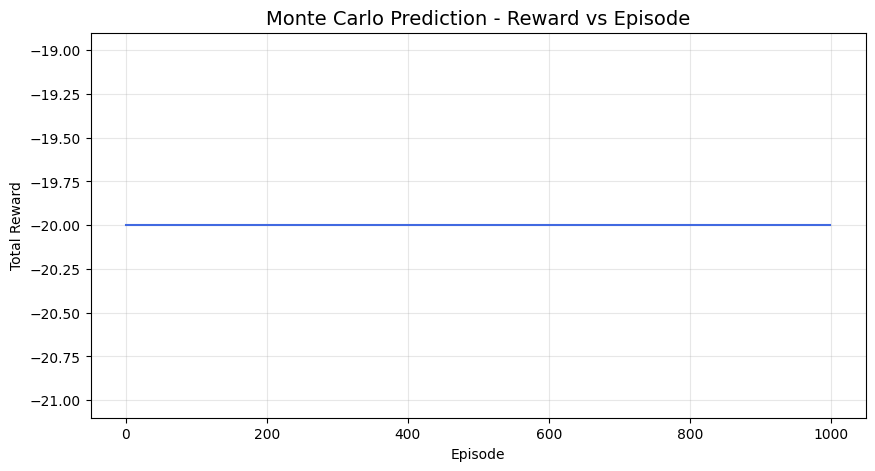

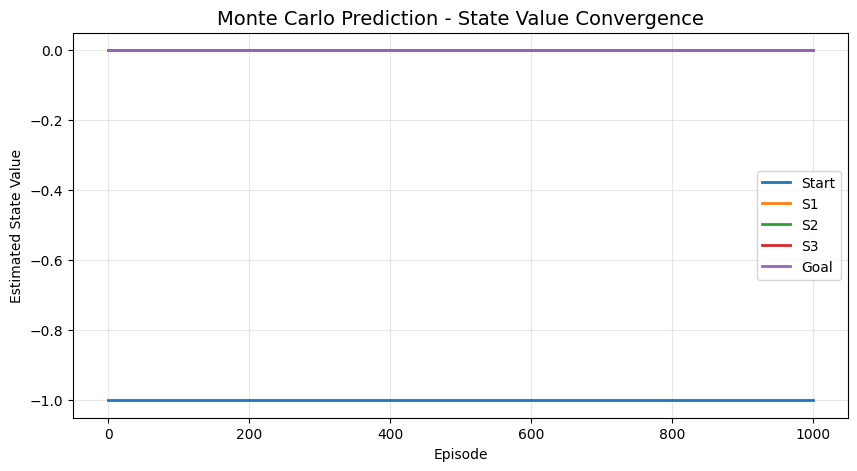

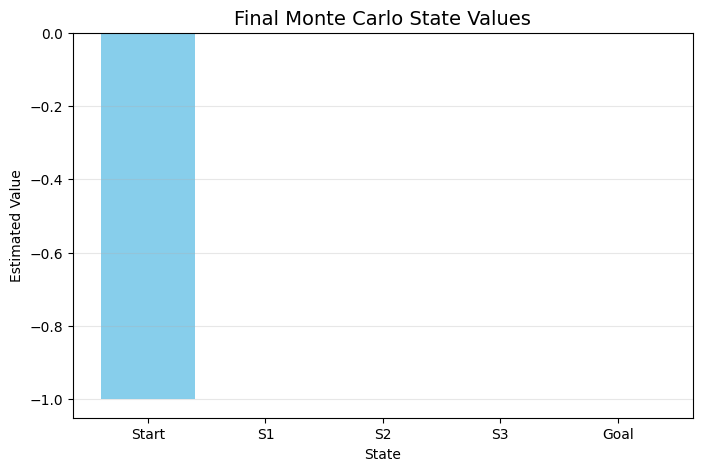

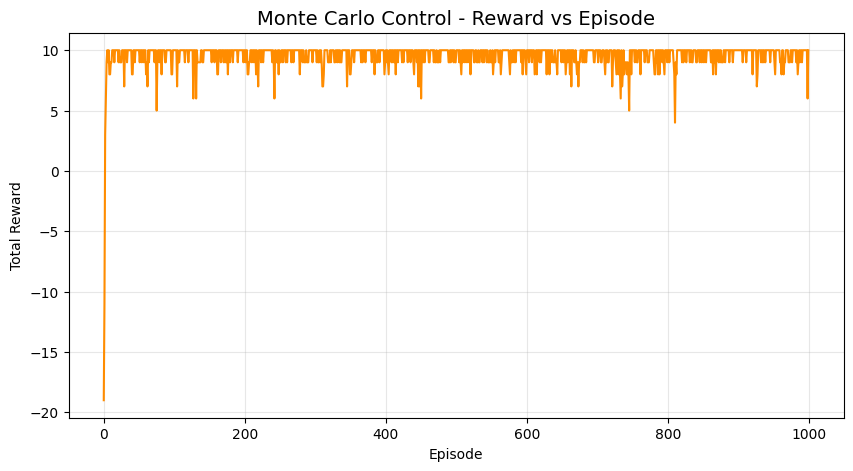

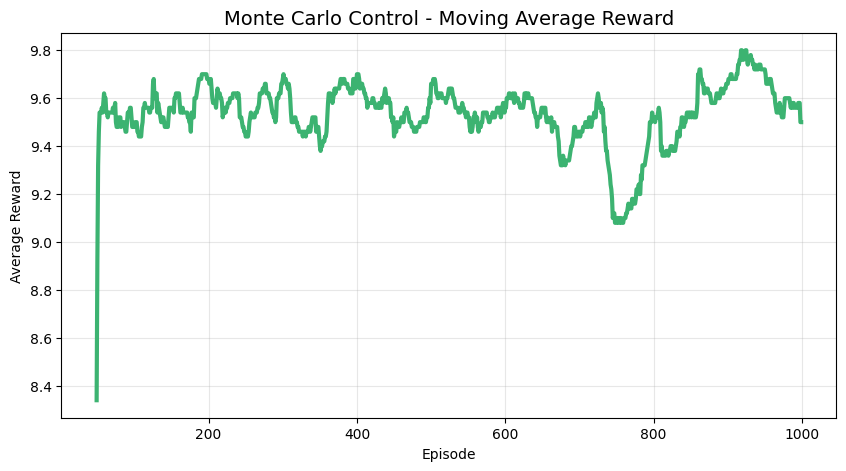

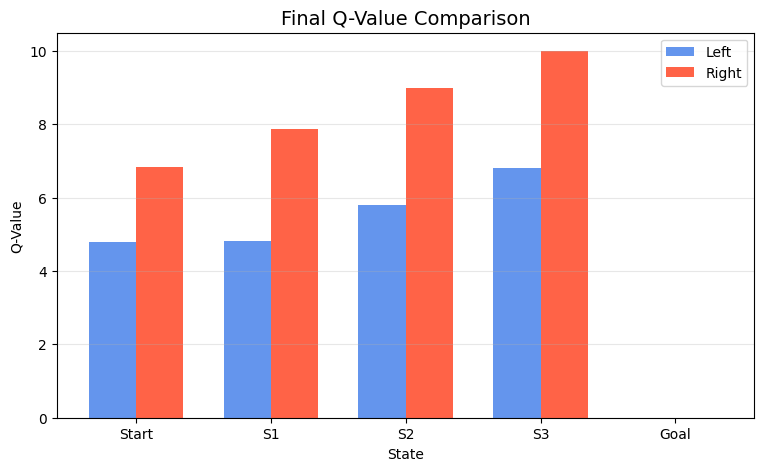

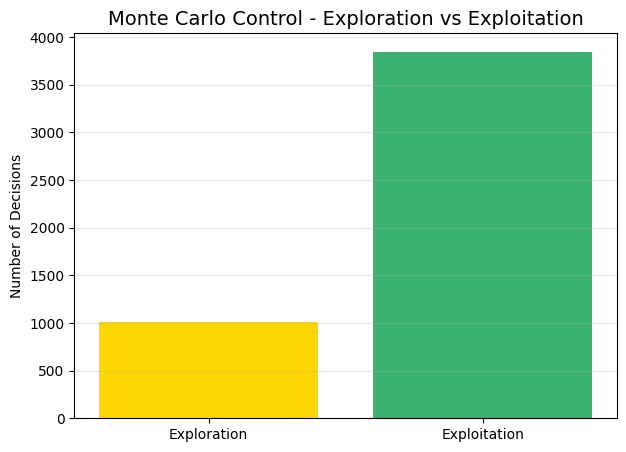

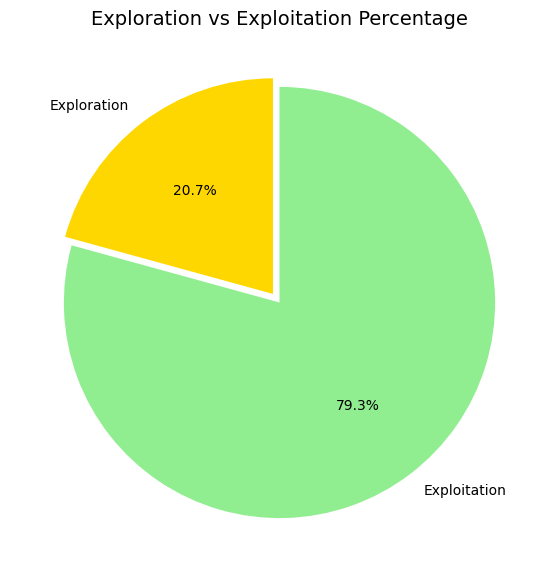

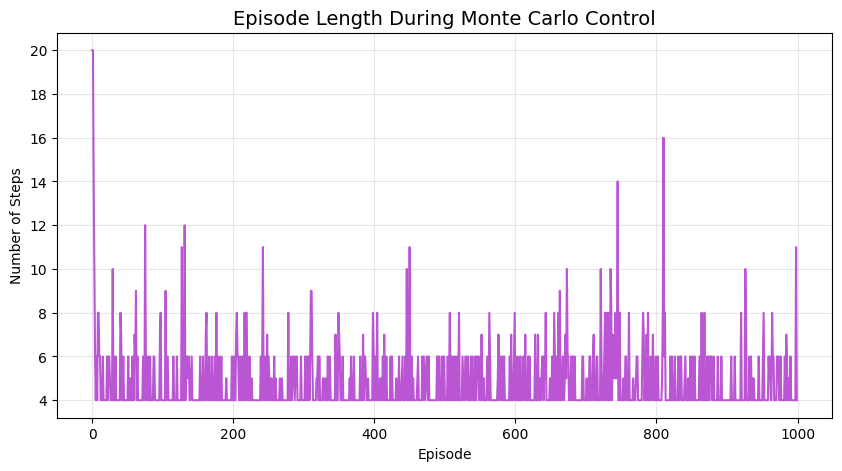

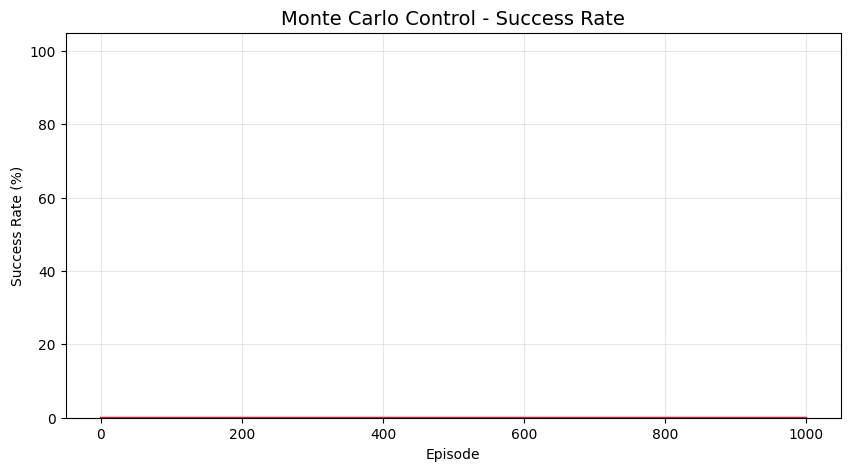



MONTE CARLO PREDICTION SUMMARY
                  Metric      Value
      Number of Episodes 1000.00000
          Average Reward  -20.00000
          Average Return   -8.78400
     Average State Value   -0.20000
     Maximum State Value    0.00000
Execution Time (seconds)    0.03184


MONTE CARLO CONTROL SUMMARY
                  Metric      Value
      Number of Episodes 1000.00000
          Average Reward    9.47500
          Average Return    6.33800
        Success Rate (%)    0.00000
  Average Episode Length    4.85000
         Average Q-Value    5.59400
         Maximum Q-Value   10.00000
Execution Time (seconds)    0.06227


PREDICTION VS CONTROL COMPARISON
                  Metric  Monte Carlo Prediction  Monte Carlo Control
          Average Reward               -20.00000              9.47500
          Average Return                -8.78400              6.33800
Execution Time (seconds)                 0.03184              0.06227


FINAL OPTIMAL POLICY
State  Left Q-Value  Ri

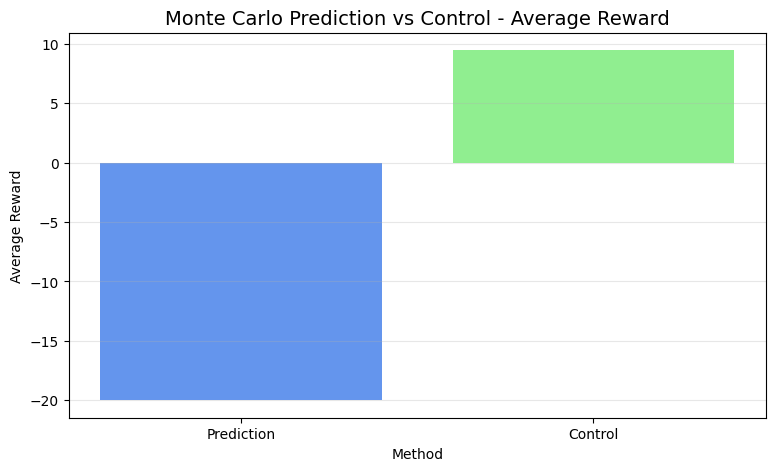



FINAL RESULT
Monte Carlo Prediction estimated the value of states
using returns collected from complete episodes.
Monte Carlo Control learned action values and
improved the policy using an epsilon-greedy strategy.
The learned optimal policy is:
Start --> Right
S1 --> Right
S2 --> Right
S3 --> Right
Goal --> Terminal


CONCLUSION
Monte Carlo Prediction and Control were successfully
implemented for a Reinforcement Learning environment.
Monte Carlo Prediction estimated the state-value function
from complete episodes without requiring a model of
the environment.
Monte Carlo Control estimated Q-values and improved the
policy using exploration and exploitation.
The learned policy guides the agent toward the Goal state.


FILES GENERATED
1. MonteCarlo_Prediction.csv
2. MonteCarlo_Control.csv
3. MonteCarlo_Q_Table.csv
4. MonteCarlo_Prediction_Summary.csv
5. MonteCarlo_Control_Summary.csv
6. Prediction_vs_Control.csv
7. MonteCarlo_Optimal_Policy.csv
8. Exploration_vs_Exploitation.csv
9. Monte

In [1]:
# ================================================================
# EXPERIMENT 6
# Monte Carlo Prediction and Control for Reinforcement Learning
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import time

print("=" * 75)
print("EXPERIMENT 6")
print("MONTE CARLO PREDICTION AND CONTROL")
print("=" * 75)

# ================================================================
# AIM
# ================================================================

print("\nAIM")
print("-" * 75)
print("To implement Monte Carlo Prediction and Monte Carlo Control")
print("for estimating state values and learning an optimal policy")
print("in a Reinforcement Learning environment.")

# ================================================================
# THEORY
# ================================================================

print("\nTHEORY")
print("-" * 75)
print("Monte Carlo methods learn from complete episodes.")
print("Monte Carlo Prediction estimates the value of states.")
print("Monte Carlo Control learns an optimal policy.")
print("The return is calculated from the rewards obtained")
print("after visiting a state.")

print("\nReturn Formula:")
print("G(t) = R(t+1) + gamma*R(t+2) + gamma^2*R(t+3) + ...")

# ================================================================
# ENVIRONMENT
# ================================================================

states = ["Start", "S1", "S2", "S3", "Goal"]

actions = ["Left", "Right"]

n_states = len(states)
n_actions = len(actions)

gamma = 0.90
alpha = 0.10
epsilon = 0.20

episodes = 1000
max_steps = 20

# ================================================================
# REWARD FUNCTION
# ================================================================

def get_next_state(state, action):

    # Start state
    if state == 0:

        if action == 0:
            return 0, -1

        else:
            return 1, 0

    # S1
    elif state == 1:

        if action == 0:
            return 0, -1

        else:
            return 2, 0

    # S2
    elif state == 2:

        if action == 0:
            return 1, -1

        else:
            return 3, 0

    # S3
    elif state == 3:

        if action == 0:
            return 2, -1

        else:
            return 4, 10

    # Goal
    else:

        return 4, 0


# ================================================================
# EPISODE GENERATION
# ================================================================

def generate_episode(policy=None, q_table=None):

    episode = []

    state = 0

    for step in range(max_steps):

        # --------------------------------------------------------
        # Choose Action
        # --------------------------------------------------------

        if q_table is not None:

            # Epsilon-greedy action selection
            if random.random() < epsilon:

                action = random.randint(0, n_actions - 1)

            else:

                action = int(np.argmax(q_table[state]))

        elif policy is not None:

            action = policy[state]

        else:

            action = random.randint(0, n_actions - 1)

        # --------------------------------------------------------
        # Environment Transition
        # --------------------------------------------------------

        next_state, reward = get_next_state(state, action)

        episode.append((state, action, reward))

        state = next_state

        # --------------------------------------------------------
        # Terminal State
        # --------------------------------------------------------

        if state == 4:

            break

    return episode


# ================================================================
# MONTE CARLO PREDICTION
# FIRST-VISIT METHOD
# ================================================================

print("\n")
print("=" * 75)
print("MONTE CARLO PREDICTION")
print("=" * 75)

prediction_start = time.time()

V_prediction = np.zeros(n_states)

returns_sum = {state: 0.0 for state in range(n_states)}

returns_count = {state: 0 for state in range(n_states)}

prediction_rewards = []
prediction_returns = []
prediction_value_history = []

# Random policy for prediction

prediction_policy = np.zeros(n_states, dtype=int)

prediction_policy[-1] = 1

for episode_number in range(episodes):

    episode = generate_episode(policy=prediction_policy)

    G = 0

    visited_states = set()

    total_reward = 0

    # ------------------------------------------------------------
    # Process episode backwards
    # ------------------------------------------------------------

    for t in range(len(episode) - 1, -1, -1):

        state, action, reward = episode[t]

        G = gamma * G + reward

        total_reward += reward

        # First-Visit Monte Carlo
        if state not in visited_states:

            visited_states.add(state)

            returns_sum[state] += G

            returns_count[state] += 1

            V_prediction[state] = (
                returns_sum[state] /
                returns_count[state]
            )

    prediction_rewards.append(total_reward)

    prediction_returns.append(G)

    prediction_value_history.append(V_prediction.copy())

prediction_time = time.time() - prediction_start

print("Monte Carlo Prediction Completed.")
print("Episodes :", episodes)
print("Execution Time :", round(prediction_time, 5), "seconds")

# ================================================================
# PREDICTION RESULTS
# ================================================================

prediction_table = pd.DataFrame({

    "State": states,

    "Estimated Value": np.round(
        V_prediction, 3
    ),

    "Visits": [
        returns_count[i]
        for i in range(n_states)
    ]

})

print("\nMonte Carlo Prediction Results")
print("-" * 75)
print(prediction_table)

prediction_table.to_csv(
    "MonteCarlo_Prediction.csv",
    index=False
)
# ================================================================
# MONTE CARLO CONTROL
# FIRST-VISIT MONTE CARLO CONTROL WITH EPSILON-GREEDY POLICY
# ================================================================

print("\n")
print("=" * 75)
print("MONTE CARLO CONTROL")
print("=" * 75)

control_start = time.time()

# ================================================================
# INITIALIZE Q-VALUES
# ================================================================

Q = np.zeros((n_states, n_actions))

# Store returns for every state-action pair

Q_returns_sum = np.zeros((n_states, n_actions))

Q_returns_count = np.zeros((n_states, n_actions))

# Initial epsilon-greedy policy

control_policy = np.zeros(n_states, dtype=int)

# Terminal state has no meaningful action

control_policy[-1] = 0

# ================================================================
# STATISTICS
# ================================================================

control_rewards = []

control_returns = []

control_steps = []

success_history = []

q_value_history = []

policy_history = []

exploration_count = 0

exploitation_count = 0

# ================================================================
# MONTE CARLO CONTROL TRAINING
# ================================================================

for episode_number in range(episodes):

    episode = []

    state = 0

    total_reward = 0

    # ------------------------------------------------------------
    # Generate complete episode
    # ------------------------------------------------------------

    for step in range(max_steps):

        # --------------------------------------------------------
        # Epsilon-Greedy Action Selection
        # --------------------------------------------------------

        if random.random() < epsilon:

            # Exploration
            action = random.randint(0, n_actions - 1)

            exploration_count += 1

        else:

            # Exploitation
            action = int(np.argmax(Q[state]))

            exploitation_count += 1

        # --------------------------------------------------------
        # Take Action
        # --------------------------------------------------------

        next_state, reward = get_next_state(
            state,
            action
        )

        episode.append(
            (state, action, reward)
        )

        total_reward += reward

        state = next_state

        # --------------------------------------------------------
        # Stop if Goal is reached
        # --------------------------------------------------------

        if state == 4:

            break

    # ------------------------------------------------------------
    # Calculate Returns Backwards
    # ------------------------------------------------------------

    G = 0

    visited_state_actions = set()

    for t in range(len(episode) - 1, -1, -1):

        state, action, reward = episode[t]

        G = gamma * G + reward

        state_action = (state, action)

        # --------------------------------------------------------
        # First-Visit State-Action Update
        # --------------------------------------------------------

        if state_action not in visited_state_actions:

            visited_state_actions.add(state_action)

            Q_returns_sum[state, action] += G

            Q_returns_count[state, action] += 1

            # ----------------------------------------------------
            # Monte Carlo Q-value
            # ----------------------------------------------------

            Q[state, action] = (
                Q_returns_sum[state, action] /
                Q_returns_count[state, action]
            )

    # ------------------------------------------------------------
    # Improve Policy
    # ------------------------------------------------------------

    for s in range(n_states - 1):

        control_policy[s] = int(
            np.argmax(Q[s])
        )

    # ------------------------------------------------------------
    # Store Statistics
    # ------------------------------------------------------------

    control_rewards.append(total_reward)

    control_returns.append(G)

    control_steps.append(len(episode))

    if state == 4:

        success_history.append(1)

    else:

        success_history.append(0)

    q_value_history.append(Q.copy())

    policy_history.append(control_policy.copy())


# ================================================================
# CONTROL EXECUTION TIME
# ================================================================

control_time = time.time() - control_start

print("Monte Carlo Control Completed.")

print("Episodes :", episodes)

print(
    "Execution Time :",
    round(control_time, 5),
    "seconds"
)

# ================================================================
# OPTIMAL POLICY
# ================================================================

action_names = {
    0: "Left",
    1: "Right"
}

optimal_policy = []

for s in range(n_states):

    if s == n_states - 1:

        optimal_policy.append("Terminal")

    else:

        optimal_policy.append(
            action_names[
                control_policy[s]
            ]
        )

# ================================================================
# DISPLAY Q-TABLE
# ================================================================

q_table = pd.DataFrame(

    Q,

    index=states,

    columns=["Left", "Right"]

)

print("\n")
print("=" * 75)
print("FINAL Q-TABLE")
print("=" * 75)

print(q_table.round(3))

# ================================================================
# DISPLAY OPTIMAL POLICY
# ================================================================

policy_table = pd.DataFrame({

    "State": states,

    "Left Q-Value": np.round(
        Q[:, 0], 3
    ),

    "Right Q-Value": np.round(
        Q[:, 1], 3
    ),

    "Optimal Action": optimal_policy

})

print("\n")
print("=" * 75)
print("OPTIMAL POLICY")
print("=" * 75)

print(policy_table)

# ================================================================
# SAVE CONTROL RESULTS
# ================================================================

policy_table.to_csv(
    "MonteCarlo_Control.csv",
    index=False
)

q_table.to_csv(
    "MonteCarlo_Q_Table.csv"
)

# ================================================================
# EXPLORATION VS EXPLOITATION
# ================================================================

print("\n")
print("=" * 75)
print("EXPLORATION VS EXPLOITATION")
print("=" * 75)

print(
    "Exploration Count :",
    exploration_count
)

print(
    "Exploitation Count :",
    exploitation_count
)

total_decisions = (
    exploration_count +
    exploitation_count
)

exploration_percentage = (
    exploration_count /
    total_decisions * 100
)

exploitation_percentage = (
    exploitation_count /
    total_decisions * 100
)

print(
    "Exploration Percentage :",
    round(exploration_percentage, 2),
    "%"
)

print(
    "Exploitation Percentage :",
    round(exploitation_percentage, 2),
    "%"
)
# ================================================================
# VISUALIZATIONS
# ================================================================

# Convert histories to NumPy arrays

prediction_value_history = np.array(
    prediction_value_history
)

q_value_history = np.array(
    q_value_history
)

policy_history = np.array(
    policy_history
)

# ================================================================
# VISUALIZATION 1
# Prediction Reward vs Episode
# ================================================================

plt.figure(figsize=(10, 5))

plt.plot(
    prediction_rewards,
    color="royalblue",
    linewidth=1.5
)

plt.title(
    "Monte Carlo Prediction - Reward vs Episode",
    fontsize=14
)

plt.xlabel("Episode")

plt.ylabel("Total Reward")

plt.grid(True, alpha=0.3)

plt.show()


# ================================================================
# VISUALIZATION 2
# Prediction State Value Convergence
# ================================================================

plt.figure(figsize=(10, 5))

for i in range(n_states):

    plt.plot(
        prediction_value_history[:, i],
        linewidth=2,
        label=states[i]
    )

plt.title(
    "Monte Carlo Prediction - State Value Convergence",
    fontsize=14
)

plt.xlabel("Episode")

plt.ylabel("Estimated State Value")

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()


# ================================================================
# VISUALIZATION 3
# Final State Values
# ================================================================

plt.figure(figsize=(8, 5))

plt.bar(
    states,
    V_prediction,
    color=[
        "skyblue",
        "lightgreen",
        "gold",
        "plum",
        "salmon"
    ]
)

plt.title(
    "Final Monte Carlo State Values",
    fontsize=14
)

plt.xlabel("State")

plt.ylabel("Estimated Value")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ================================================================
# VISUALIZATION 4
# Control Reward vs Episode
# ================================================================

plt.figure(figsize=(10, 5))

plt.plot(
    control_rewards,
    color="darkorange",
    linewidth=1.5
)

plt.title(
    "Monte Carlo Control - Reward vs Episode",
    fontsize=14
)

plt.xlabel("Episode")

plt.ylabel("Total Reward")

plt.grid(True, alpha=0.3)

plt.show()


# ================================================================
# VISUALIZATION 5
# Moving Average Reward
# ================================================================

window = 50

if len(control_rewards) >= window:

    moving_average = (
        pd.Series(control_rewards)
        .rolling(window)
        .mean()
    )

else:

    moving_average = control_rewards

plt.figure(figsize=(10, 5))

plt.plot(
    moving_average,
    color="mediumseagreen",
    linewidth=3
)

plt.title(
    "Monte Carlo Control - Moving Average Reward",
    fontsize=14
)

plt.xlabel("Episode")

plt.ylabel("Average Reward")

plt.grid(True, alpha=0.3)

plt.show()


# ================================================================
# VISUALIZATION 6
# Q-Value Comparison
# ================================================================

x = np.arange(n_states)

width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    Q[:, 0],
    width,
    label="Left",
    color="cornflowerblue"
)

plt.bar(
    x + width / 2,
    Q[:, 1],
    width,
    label="Right",
    color="tomato"
)

plt.xticks(
    x,
    states
)

plt.title(
    "Final Q-Value Comparison",
    fontsize=14
)

plt.xlabel("State")

plt.ylabel("Q-Value")

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ================================================================
# VISUALIZATION 7
# Exploration vs Exploitation
# ================================================================

plt.figure(figsize=(7, 5))

plt.bar(
    ["Exploration", "Exploitation"],
    [
        exploration_count,
        exploitation_count
    ],
    color=[
        "gold",
        "mediumseagreen"
    ]
)

plt.title(
    "Monte Carlo Control - Exploration vs Exploitation",
    fontsize=14
)

plt.ylabel("Number of Decisions")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ================================================================
# VISUALIZATION 8
# Exploration vs Exploitation Percentage
# ================================================================

plt.figure(figsize=(7, 7))

plt.pie(
    [
        exploration_count,
        exploitation_count
    ],
    labels=[
        "Exploration",
        "Exploitation"
    ],
    autopct="%1.1f%%",
    startangle=90,
    colors=[
        "gold",
        "lightgreen"
    ],
    explode=[
        0.05,
        0
    ]
)

plt.title(
    "Exploration vs Exploitation Percentage",
    fontsize=14
)

plt.show()


# ================================================================
# VISUALIZATION 9
# Episode Length
# ================================================================

plt.figure(figsize=(10, 5))

plt.plot(
    control_steps,
    color="mediumorchid",
    linewidth=1.5
)

plt.title(
    "Episode Length During Monte Carlo Control",
    fontsize=14
)

plt.xlabel("Episode")

plt.ylabel("Number of Steps")

plt.grid(True, alpha=0.3)

plt.show()


# ================================================================
# VISUALIZATION 10
# Success Rate
# ================================================================

success_rate_history = []

for i in range(1, len(success_history) + 1):

    success_rate_history.append(
        np.mean(success_history[:i]) * 100
    )

plt.figure(figsize=(10, 5))

plt.plot(
    success_rate_history,
    color="crimson",
    linewidth=2.5
)

plt.title(
    "Monte Carlo Control - Success Rate",
    fontsize=14
)

plt.xlabel("Episode")

plt.ylabel("Success Rate (%)")

plt.ylim(0, 105)

plt.grid(True, alpha=0.3)

plt.show()
# ================================================================
# FINAL SUMMARY AND PERFORMANCE ANALYSIS
# ================================================================

# ------------------------------------------------
# Calculate Final Metrics
# ------------------------------------------------

prediction_average_reward = np.mean(
    prediction_rewards
)

prediction_average_return = np.mean(
    prediction_returns
)

control_average_reward = np.mean(
    control_rewards
)

control_average_return = np.mean(
    control_returns
)

control_success_rate = (
    np.mean(success_history) * 100
)

average_episode_length = np.mean(
    control_steps
)

maximum_q_value = np.max(Q)

average_q_value = np.mean(Q)

final_prediction_value = np.mean(
    V_prediction
)

# ------------------------------------------------
# Prediction Summary
# ------------------------------------------------

prediction_summary = pd.DataFrame({

    "Metric": [
        "Number of Episodes",
        "Average Reward",
        "Average Return",
        "Average State Value",
        "Maximum State Value",
        "Execution Time (seconds)"
    ],

    "Value": [
        episodes,
        round(prediction_average_reward, 3),
        round(prediction_average_return, 3),
        round(final_prediction_value, 3),
        round(np.max(V_prediction), 3),
        round(prediction_time, 5)
    ]
})

print("\n")
print("=" * 75)
print("MONTE CARLO PREDICTION SUMMARY")
print("=" * 75)

print(prediction_summary.to_string(index=False))


# ------------------------------------------------
# Control Summary
# ------------------------------------------------

control_summary = pd.DataFrame({

    "Metric": [
        "Number of Episodes",
        "Average Reward",
        "Average Return",
        "Success Rate (%)",
        "Average Episode Length",
        "Average Q-Value",
        "Maximum Q-Value",
        "Execution Time (seconds)"
    ],

    "Value": [
        episodes,
        round(control_average_reward, 3),
        round(control_average_return, 3),
        round(control_success_rate, 2),
        round(average_episode_length, 2),
        round(average_q_value, 3),
        round(maximum_q_value, 3),
        round(control_time, 5)
    ]
})

print("\n")
print("=" * 75)
print("MONTE CARLO CONTROL SUMMARY")
print("=" * 75)

print(control_summary.to_string(index=False))


# ================================================================
# PREDICTION VS CONTROL COMPARISON
# ================================================================

comparison = pd.DataFrame({

    "Metric": [
        "Average Reward",
        "Average Return",
        "Execution Time (seconds)"
    ],

    "Monte Carlo Prediction": [
        round(prediction_average_reward, 3),
        round(prediction_average_return, 3),
        round(prediction_time, 5)
    ],

    "Monte Carlo Control": [
        round(control_average_reward, 3),
        round(control_average_return, 3),
        round(control_time, 5)
    ]
})

print("\n")
print("=" * 75)
print("PREDICTION VS CONTROL COMPARISON")
print("=" * 75)

print(comparison.to_string(index=False))


# ================================================================
# OPTIMAL POLICY TABLE
# ================================================================

optimal_policy_table = pd.DataFrame({

    "State": states,

    "Left Q-Value": np.round(
        Q[:, 0], 3
    ),

    "Right Q-Value": np.round(
        Q[:, 1], 3
    ),

    "Optimal Action": optimal_policy
})

print("\n")
print("=" * 75)
print("FINAL OPTIMAL POLICY")
print("=" * 75)

print(
    optimal_policy_table.to_string(
        index=False
    )
)


# ================================================================
# EXPLORATION VS EXPLOITATION TABLE
# ================================================================

exploration_table = pd.DataFrame({

    "Strategy": [
        "Exploration",
        "Exploitation"
    ],

    "Count": [
        exploration_count,
        exploitation_count
    ],

    "Percentage": [
        round(
            exploration_percentage,
            2
        ),

        round(
            exploitation_percentage,
            2
        )
    ]
})

print("\n")
print("=" * 75)
print("EXPLORATION VS EXPLOITATION SUMMARY")
print("=" * 75)

print(
    exploration_table.to_string(
        index=False
    )
)


# ================================================================
# SAVE CSV FILES
# ================================================================

prediction_summary.to_csv(
    "MonteCarlo_Prediction_Summary.csv",
    index=False
)

control_summary.to_csv(
    "MonteCarlo_Control_Summary.csv",
    index=False
)

comparison.to_csv(
    "Prediction_vs_Control.csv",
    index=False
)

optimal_policy_table.to_csv(
    "MonteCarlo_Optimal_Policy.csv",
    index=False
)

exploration_table.to_csv(
    "Exploration_vs_Exploitation.csv",
    index=False
)


# ================================================================
# COMBINED SUMMARY TABLE
# ================================================================

combined_summary = pd.DataFrame({

    "Algorithm": [
        "Monte Carlo Prediction",
        "Monte Carlo Control"
    ],

    "Average Reward": [
        round(
            prediction_average_reward,
            3
        ),
        round(
            control_average_reward,
            3
        )
    ],

    "Average Return": [
        round(
            prediction_average_return,
            3
        ),
        round(
            control_average_return,
            3
        )
    ],

    "Execution Time": [
        round(
            prediction_time,
            5
        ),
        round(
            control_time,
            5
        )
    ],

    "Episodes": [
        episodes,
        episodes
    ]
})

print("\n")
print("=" * 75)
print("FINAL COMBINED SUMMARY")
print("=" * 75)

print(
    combined_summary.to_string(
        index=False
    )
)

combined_summary.to_csv(
    "MonteCarlo_Final_Summary.csv",
    index=False
)


# ================================================================
# FINAL PERFORMANCE GRAPH
# ================================================================

plt.figure(figsize=(9, 5))

plt.bar(
    ["Prediction", "Control"],
    [
        prediction_average_reward,
        control_average_reward
    ],
    color=[
        "cornflowerblue",
        "lightgreen"
    ]
)

plt.title(
    "Monte Carlo Prediction vs Control - Average Reward",
    fontsize=14
)

plt.xlabel("Method")

plt.ylabel("Average Reward")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ================================================================
# FINAL RESULT
# ================================================================

print("\n")
print("=" * 75)
print("FINAL RESULT")
print("=" * 75)

print(
    "Monte Carlo Prediction estimated the value of states"
)

print(
    "using returns collected from complete episodes."
)

print(
    "Monte Carlo Control learned action values and"
)

print(
    "improved the policy using an epsilon-greedy strategy."
)

print(
    "The learned optimal policy is:"
)

for state, action in zip(
    states,
    optimal_policy
):

    print(
        f"{state} --> {action}"
    )


# ================================================================
# CONCLUSION
# ================================================================

print("\n")
print("=" * 75)
print("CONCLUSION")
print("=" * 75)

print(
    "Monte Carlo Prediction and Control were successfully"
)

print(
    "implemented for a Reinforcement Learning environment."
)

print(
    "Monte Carlo Prediction estimated the state-value function"
)

print(
    "from complete episodes without requiring a model of"
)

print(
    "the environment."
)

print(
    "Monte Carlo Control estimated Q-values and improved the"
)

print(
    "policy using exploration and exploitation."
)

print(
    "The learned policy guides the agent toward the Goal state."
)


# ================================================================
# GENERATED FILES
# ================================================================

print("\n")
print("=" * 75)
print("FILES GENERATED")
print("=" * 75)

print("1. MonteCarlo_Prediction.csv")
print("2. MonteCarlo_Control.csv")
print("3. MonteCarlo_Q_Table.csv")
print("4. MonteCarlo_Prediction_Summary.csv")
print("5. MonteCarlo_Control_Summary.csv")
print("6. Prediction_vs_Control.csv")
print("7. MonteCarlo_Optimal_Policy.csv")
print("8. Exploration_vs_Exploitation.csv")
print("9. MonteCarlo_Final_Summary.csv")

print("\n")
print("=" * 75)
print("EXPERIMENT 6 COMPLETED SUCCESSFULLY")
print("=" * 75)